# 02 — Event Study: CAR Around ETF Reconstitution

**研究標的**：00919 調入股  
**方法**：Market-adjusted abnormal return（無 beta 估計）  
**事件日**：相對交易日 0 = 公告日  

若 `data/processed/stock_prices.parquet` 或 `data/raw/events.csv` 尚未備妥，  
本 notebook 會自動產生 synthetic data（3 個事件、12 檔股票）供驗證用。

In [1]:
import sys
import logging
from pathlib import Path

import numpy as np
import pandas as pd

# src/ is one level up
sys.path.insert(0, str(Path("../src").resolve()))

from data_fetcher import load_events
from event_study import (
    aggregate_cars_across_events,
    plot_average_car,
    t_test_car,
)

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(name)s — %(message)s",
)

PARQUET_PATH = Path("../data/processed/stock_prices.parquet")
EVENTS_PATH  = Path("../data/raw/events.csv")
FIG_PATH     = Path("../output/figures/car_curve_added_stocks.png")

## 1. 載入資料（或產生 synthetic data）

In [2]:
USE_SYNTHETIC = not (PARQUET_PATH.exists() and EVENTS_PATH.exists())

if USE_SYNTHETIC:
    print("⚠️  真實資料不存在，使用 synthetic data 驗證程式碼")
else:
    print("✅ 載入真實資料")

⚠️  真實資料不存在，使用 synthetic data 驗證程式碼


In [3]:
# ════════════════════════════════════════════════════════════════
# ⛔  DEPRECATED — 此 cell 產生合成資料，禁止在真實研究中執行
# ════════════════════════════════════════════════════════════════
raise RuntimeError(
    "合成資料已停用。請先建立真實資料 (data/raw/events.csv + "
    "data/processed/stock_prices.parquet) 再執行本 notebook。"
)

# ── 以下為原合成資料程式碼，僅供參考 ──
# ── Synthetic data generator ──────────────────────────────────────────────────

def _make_synthetic_data():
    """Generate reproducible toy data that shows a recognisable CAR pattern.
    
    Pattern: pre-announcement drift → jump on day 0 → partial reversal post-effective.
    """
    rng = np.random.default_rng(seed=42)
    trading_days = pd.bdate_range("2021-01-01", "2024-12-31")
    n = len(trading_days)

    # ── Build TAIEX (pure GBM, no event shocks) ──
    taiex_rets = rng.normal(0.0003, 0.007, size=n - 1)
    taiex_px   = np.concatenate([[17_000.0], 17_000.0 * np.cumprod(1 + taiex_rets)])

    # ── Build 12 stock return series (base GBM) ──
    sids = [f"S{i:03d}" for i in range(1, 13)]
    base_rets = {sid: rng.normal(0.0002, 0.014, size=n - 1) for sid in sids}

    # ── Event definitions ──
    raw_events = [
        dict(event_id=1, etf_code="00919",
             announcement_date="2022-06-15", effective_date="2022-06-22",
             added=["S001", "S002", "S003", "S004"],
             removed=["S005", "S006"]),
        dict(event_id=2, etf_code="00919",
             announcement_date="2022-12-14", effective_date="2022-12-21",
             added=["S007", "S008", "S009"],
             removed=["S010"]),
        dict(event_id=3, etf_code="00919",
             announcement_date="2023-06-13", effective_date="2023-06-20",
             added=["S001", "S011", "S012"],
             removed=["S002", "S003"]),
    ]

    # ── Inject shocks into added-stock returns ──
    # Pattern: slow pre-drift (day -10 to -1) + big jump (day 0) +
    #          momentum (day 1–5) + reversal (day 6–30)
    shock_profile = {}
    for d in range(-10, -1):  shock_profile[d]  = +0.0015   # subtle pre-drift
    shock_profile[0]              = +0.018                    # announcement jump
    for d in range(1, 6):    shock_profile[d]  = +0.004     # momentum
    for d in range(6, 31):   shock_profile[d]  = -0.0025    # partial reversal

    for ev in raw_events:
        ann = pd.Timestamp(ev["announcement_date"])
        future = trading_days[trading_days >= ann]
        t0_idx = trading_days.get_loc(future[0])
        for sid in ev["added"]:
            for offset, shock in shock_profile.items():
                idx = t0_idx + offset  # position in the returns array = price_idx - 1
                if 0 <= idx < len(base_rets[sid]):
                    base_rets[sid][idx] += shock

    # ── Build price DataFrame (long format matching data_fetcher output) ──
    all_prices = {"TAIEX": taiex_px}
    for sid in sids:
        px = np.concatenate([[100.0], 100.0 * np.cumprod(1 + base_rets[sid])])
        all_prices[sid] = px

    prices_wide = pd.DataFrame(all_prices, index=trading_days)
    prices_wide.index.name = "date"

    # ── Build events DataFrame (matches load_events() output) ──
    events_rows = []
    for ev in raw_events:
        events_rows.append({
            "event_id":          ev["event_id"],
            "etf_code":          ev["etf_code"],
            "announcement_date": pd.Timestamp(ev["announcement_date"]),
            "effective_date":    pd.Timestamp(ev["effective_date"]),
            "added_stocks":      ev["added"],
            "removed_stocks":    ev["removed"],
        })
    events = pd.DataFrame(events_rows)

    return prices_wide, events

## 2. 建立分析所需的 prices_wide 和 market_returns

In [4]:
if USE_SYNTHETIC:
    prices_wide, events = _make_synthetic_data()

else:
    # ── 真實資料路徑 ──────────────────────────────────────────────────────────
    # stock_prices.parquet 格式假設：
    #   長格式，DatetimeIndex (= date)，columns 包含 stock_id、close
    #   TAIEX 以 stock_id="TAIEX" 存在同一個檔案
    long_df = pd.read_parquet(PARQUET_PATH)

    # 若 date 是欄位而非 index，設為 index
    if "date" in long_df.columns:
        long_df = long_df.set_index("date")
    long_df.index = pd.to_datetime(long_df.index)

    # Pivot → 寬格式：index = date，columns = stock_id，values = close
    prices_wide = (
        long_df
        .reset_index()
        .pivot(index="date", columns="stock_id", values="close")
        .sort_index()
    )
    prices_wide.columns.name = None

    events = load_events(EVENTS_PATH)

print(f"prices_wide: {prices_wide.shape}  ({prices_wide.index[0].date()} → {prices_wide.index[-1].date()})")
print(f"columns (first 10): {list(prices_wide.columns[:10])}")
print(f"events: {len(events)} rows")
events.head()

prices_wide: (1043, 13)  (2021-01-01 → 2024-12-31)
columns (first 10): ['TAIEX', 'S001', 'S002', 'S003', 'S004', 'S005', 'S006', 'S007', 'S008', 'S009']
events: 3 rows


,event_id,etf_code,announcement_date,effective_date,added_stocks,removed_stocks
0,1,00919,2022-06-15,2022-06-22,"[S001, S002, S003, S004]","[S005, S006]"
1,2,00919,2022-12-14,2022-12-21,"[S007, S008, S009]",[S010]
2,3,00919,2023-06-13,2023-06-20,"[S001, S011, S012]","[S002, S003]"


In [5]:
# ── Market returns（TAIEX 簡單報酬）──────────────────────────────────────────
if "TAIEX" not in prices_wide.columns:
    raise ValueError(
        "TAIEX 不在 prices_wide 中。\n"
        "請確認 stock_prices.parquet 包含 TAIEX，或另外 fetch_market_index() 後合併。"
    )

market_returns = prices_wide["TAIEX"].pct_change().rename("market_ret")
print(f"market_returns: {market_returns.notna().sum()} non-null days")
market_returns.describe()

market_returns: 1042 non-null days


count    1042.000000
mean        0.000093
std         0.006885
min        -0.025239
25%        -0.004506
50%         0.000343
75%         0.004530
max         0.022552
Name: market_ret, dtype: float64

## 3. 計算生效日偏移量（relative_day）

In [6]:
trading_days = prices_wide.index

def _trading_day_offset(start: pd.Timestamp, end: pd.Timestamp) -> int:
    """Number of trading days from start (inclusive) to end (inclusive)."""
    start_td = trading_days[trading_days >= start]
    end_td   = trading_days[trading_days >= end]
    if start_td.empty or end_td.empty:
        return np.nan
    i0 = trading_days.get_loc(start_td[0])
    i1 = trading_days.get_loc(end_td[0])
    return i1 - i0

offsets = events.apply(
    lambda r: _trading_day_offset(r["announcement_date"], r["effective_date"]),
    axis=1,
).dropna()

effective_day = int(offsets.median())
print(f"生效日偏移量（各事件）: {offsets.values.tolist()}")
print(f"使用中位數：effective_day = {effective_day}")

生效日偏移量（各事件）: [5, 5, 5]
使用中位數：effective_day = 5


## 4. 聚合 CAR（調入股）

In [7]:
EVENT_WINDOW = (-30, 60)

agg_added = aggregate_cars_across_events(
    events=events,
    prices_wide=prices_wide,
    market_returns=market_returns,
    event_window=EVENT_WINDOW,
    stock_col="added_stocks",
)

print(f"聚合結果：{len(agg_added)} relative_day 筆")
print(f"N 範圍：{agg_added['N'].min()} – {agg_added['N'].max()} obs/day")
agg_added.head(10)

聚合結果：91 relative_day 筆
N 範圍：10 – 10 obs/day


,relative_day,mean_AR,mean_CAR,std_CAR,N
0,-30,-0.001460,-0.001460,0.011862,10
1,-29,0.003360,0.001900,0.020949,10
2,-28,-0.001524,0.000376,0.017444,10
3,-27,-0.011949,-0.011574,0.018784,10
4,-26,-0.009044,-0.020617,0.021509,10
5,-25,0.002381,-0.018236,0.023628,10
6,-24,-0.001188,-0.019425,0.036298,10
7,-23,-0.003436,-0.022861,0.032635,10
8,-22,0.005325,-0.017536,0.035615,10
9,-21,0.004184,-0.013352,0.034185,10


In [8]:
# 關鍵節點的 CAR 快速檢視
key_days = [-5, -1, 0, 1, 5, effective_day, 30, 60]
(
    agg_added
    .set_index("relative_day")
    .loc[[d for d in key_days if d in agg_added["relative_day"].values],
         ["mean_AR", "mean_CAR", "N"]]
    .assign(
        mean_AR=lambda df: df["mean_AR"].map("{:.4%}".format),
        mean_CAR=lambda df: df["mean_CAR"].map("{:.4%}".format),
    )
)

,mean_AR,mean_CAR,N
relative_day,,,
-5,-0.0958%,-1.9896%,10
-1,0.0745%,-1.9104%,10
0,0.0407%,-1.8696%,10
1,1.4691%,-0.4006%,10
5,1.0768%,0.9344%,10
5,1.0768%,0.9344%,10
30,0.0529%,-1.3717%,10
60,0.8353%,2.2241%,10


## 5. 統計檢定：公告日至生效日 CAR

In [9]:
# 公告日至生效日的 CAR t-test
result_ann = t_test_car(
    events=events,
    prices_wide=prices_wide,
    market_returns=market_returns,
    window=(0, effective_day),
    stock_col="added_stocks",
)
result_ann


──────────────────────────────────────────────────
  One-sample t-test  H₀: mean CAR = 0
  Window : day 0 to 5  |  col: added_stocks
──────────────────────────────────────────────────
  N         : 10
  Mean CAR  : +0.0284  (2.84%)
  Std CAR   : 0.0298
  t-stat    : 3.0212
  p-value   : 0.0145  **
──────────────────────────────────────────────────



,window,N,mean_CAR,std_CAR,t_stat,p_value
0,"[0, 5]",10,0.028447,0.029775,3.02124,0.01445


In [10]:
# 生效日後 30 天的 CAR t-test（reversal 檢定）
result_rev = t_test_car(
    events=events,
    prices_wide=prices_wide,
    market_returns=market_returns,
    window=(effective_day + 1, 30),
    stock_col="added_stocks",
)
result_rev


──────────────────────────────────────────────────
  One-sample t-test  H₀: mean CAR = 0
  Window : day 6 to 30  |  col: added_stocks
──────────────────────────────────────────────────
  N         : 10
  Mean CAR  : -0.0231  (-2.31%)
  Std CAR   : 0.0581
  t-stat    : -1.2551
  p-value   : 0.2411  
──────────────────────────────────────────────────



,window,N,mean_CAR,std_CAR,t_stat,p_value
0,"[6, 30]",10,-0.023061,0.058103,-1.255076,0.24106


## 6. CAR 曲線圖

2026-05-17 18:34:35,625 [INFO] event_study — CAR chart saved → ../output/figures/car_curve_added_stocks.png


圖檔存至：/Users/liuyenzhen/.claude/worktrees/nervous-cohen-8003bf/output/figures/car_curve_added_stocks.png


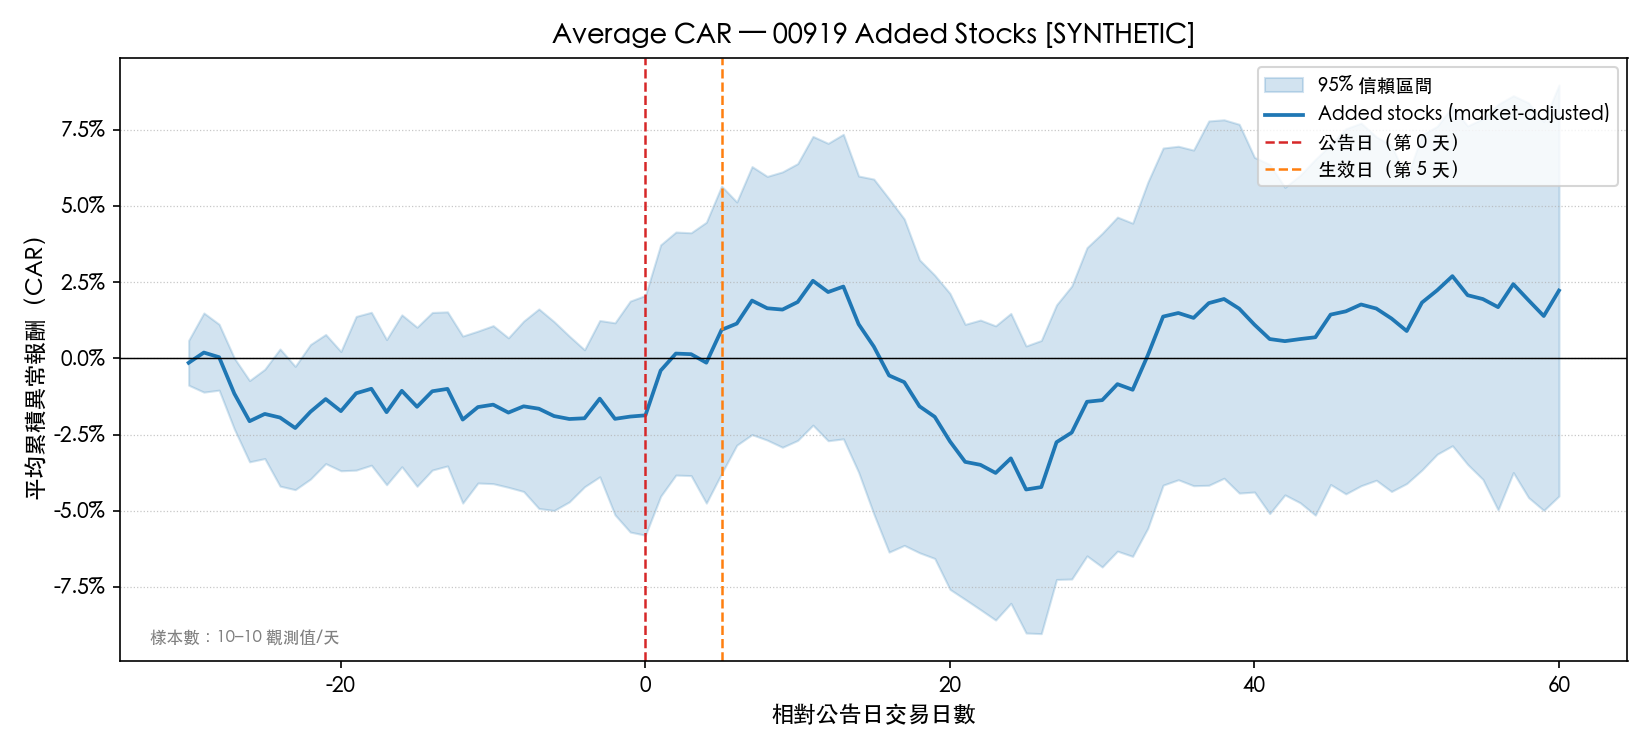

In [11]:
data_tag = "[SYNTHETIC]" if USE_SYNTHETIC else ""

plot_average_car(
    aggregated_df=agg_added,
    save_path=FIG_PATH,
    effective_day=effective_day,
    title=f"Average CAR — 00919 Added Stocks {data_tag}",
    label="Added stocks (market-adjusted)",
)

print(f"圖檔存至：{FIG_PATH.resolve()}")

# 在 notebook 中顯示
from IPython.display import Image
Image(FIG_PATH)